VANGUARD PROJECT - Customer Journey Reconstruction & Completion Time KPI

QUESTION : How will you reconstruct customer journeys from the web event logs?

In this notebook we will explore and reconstruct : SUCCESSFUL Journey --> The journey follows the expected sequence and reaches confirmation:  
START → STEP_1 → STEP_2 → STEP_3 → CONFIRM
Objective: Reconstruct each customer's journey through the process (start → step_1 → step_2 → step_3 → confirm), isolate only the journeys that "successfully complete the expected sequence", and measure "completion time" as a KPI to compare Test vs. Control groups.

Key definitions to establish in this notebook
- **Successful completion:** a journey that follows the exact expected step order and reaches `confirm`, with no skipped steps.
- **Unit of analysis:** completion is measured at the **journey (`visit_id`) level**, since a single client can have multiple visits, and not all visits represent an "attempt" at the
  same journey. Completion time is calculated per journey, then optionally aggregated per client for reporting.
- **Journey start/end timestamps:** start = timestamp of the first `start` event in that visit; end = timestamp of the first `confirm` event in that visit (not the last, to avoid
  inflating time with repeated confirm clicks).
- **Long completion times:** identified via IQR, not deleted — flagged and reported both with and without them so the KPI isn't silently distorted either way.

DATASET: df_final_web_data Pt1 : https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt df_final_web_data Pt2 : https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt df_final_experiment_clients : https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt
df_demo : https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt

CHECKLIST:

Which analytical decisions are required before customer behaviour can be measured? What constitutes a successful completion? Should completion be measured at the client level or the journey level? Completion Time --> Measures: The total time required for a customer to complete the process. Which timestamps define the beginning and the end of a journey? How should exceptionally long completion times be handled? Should completion time be measured per journey or per customer? Effective Time --> Measures: The amount of time customers actively spend progressing through the process. Unlike Completion Time, this KPI attempts to capture the time spent making forward progress rather than the total elapsed duration of the journey. Do your KPIs provide a reliable description of customer behaviour? Do your KPIs accurately represent customer behaviour? Prepare for Statistical Analysis : Identify which KPIs will be compared between the Control and Test groups. Identify any assumptions that should be checked before performing statistical Are your KPIs ready to support a fair statistical comparison between the Control and Test groups?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
url_pt1 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt"
url_pt2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt"
url_exp = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt"
url_demo = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
df1 = pd.read_csv(url_pt1)
df2 = pd.read_csv(url_pt2)
df_exp = pd.read_csv(url_exp)
df_demo = pd.read_csv(url_demo)

print(df1.shape, df2.shape, df_exp.shape, df_demo.shape)

(343141, 5) (412264, 5) (70609, 2) (70609, 9)


In [3]:
# Combine web data and convert time 


df_web = pd.concat([df1, df2], axis=0, ignore_index=True)
df_web['date_time'] = pd.to_datetime(df_web['date_time'], errors='coerce')

print(df_web.shape)
df_web.head()

(755405, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


Before filtering: (755405, 6)
After filtering to experiment clients: (321309, 6)

In [4]:
# Merge in Variation, filter to experiment clients only

df_web = pd.merge(df_web, df_exp, on='client_id', how='left')

# Filter out clients not part of the experiment (preview before/after)
df_web_all = df_web.copy()                          # keep full version for reference
df_web = df_web[df_web['Variation'].notnull()]      # filtered working version

print(f"Before filtering: {df_web_all.shape}")
print(f"After filtering to experiment clients: {df_web.shape}")
df_web['Variation'].value_counts()

Before filtering: (755405, 6)
After filtering to experiment clients: (321309, 6)


Variation
Test       177847
Control    143462
Name: count, dtype: int64

creating a numeric order for process_step to check whether a journey moves through the steps in the correct sequence, not just whether all 5 steps happen to be present.

In [5]:
# Map process_step to a numeric order

step_order_map = {
    'start': 0,
    'step_1': 1,
    'step_2': 2,
    'step_3': 3,
    'confirm': 4
}
df_web['step_order'] = df_web['process_step'].map(step_order_map)

# Sort so every visit's events are in chronological order
df_web = df_web.sort_values(by=['visit_id', 'date_time']).reset_index(drop=True)

For each visit_id, we collect:
the full sequence of steps visited, in time order (with consecutive duplicates collapsed — e.g. start, start, step_1 becomes start, step_1)
the first start timestamp
the first confirm timestamp (if any)
the client and Variation for that visit

In [6]:
# Build one row per visit_id (journey-level table)

def build_journey(group):
    # Collapse consecutive duplicate steps (e.g. step_2, step_2 -> step_2)
    steps_in_order = group['process_step'].tolist()
    collapsed = [steps_in_order[0]]
    for s in steps_in_order[1:]:
        if s != collapsed[-1]:
            collapsed.append(s)

    return pd.Series({
        'client_id': group['client_id'].iloc[0],
        'Variation': group['Variation'].iloc[0],
        'step_sequence': collapsed,
        'start_time': group.loc[group['process_step'] == 'start', 'date_time'].min(),
        'confirm_time': group.loc[group['process_step'] == 'confirm', 'date_time'].min(),
        'n_events': len(group)
    })

journeys = df_web.groupby('visit_id').apply(build_journey, include_groups=False).reset_index()

print(journeys.shape)
journeys.head()

(69205, 7)


,visit_id,client_id,Variation,step_sequence,start_time,confirm_time,n_events
0,100012776_37918976071_457913,3561384,Test,[confirm],NaT,2017-04-26 13:22:17,2
1,100019538_17884295066_43909,7338123,Test,"[start, step_1, step_2, step_1, start, step_1,...",2017-04-09 16:20:56,2017-04-09 16:24:58,11
2,100022086_87870757897_149620,2478628,Test,"[start, step_1, step_2, step_3, confirm]",2017-05-23 20:44:01,2017-05-23 20:47:01,5
3,100030127_47967100085_936361,105007,Control,[start],2017-03-22 11:07:49,NaT,1
4,100037962_47432393712_705583,5623007,Control,"[start, step_1, start]",2017-04-14 16:41:51,NaT,4


Without collapsing repeated steps 

In [7]:
# Build one row per visit_id without collapsing repeated steps

def build_journey_raw(group):

    return pd.Series({
        'client_id': group['client_id'].iloc[0],
        'Variation': group['Variation'].iloc[0],
        'step_sequence': group['process_step'].tolist(), # keep all steps
        'start_time': group.loc[group['process_step']=='start', 'date_time'].min(),
        'confirm_time': group.loc[group['process_step']=='confirm', 'date_time'].min(),
        'n_events': len(group)
})

journeys_raw = (
    df_web
    .sort_values(['visit_id', 'date_time'])
    .groupby('visit_id')
    .apply(build_journey_raw, include_groups=False)
    .reset_index()
)

journeys_raw.head()

,visit_id,client_id,Variation,step_sequence,start_time,confirm_time,n_events
0,100012776_37918976071_457913,3561384,Test,"[confirm, confirm]",NaT,2017-04-26 13:22:17,2
1,100019538_17884295066_43909,7338123,Test,"[start, step_1, step_2, step_1, step_1, start,...",2017-04-09 16:20:56,2017-04-09 16:24:58,11
2,100022086_87870757897_149620,2478628,Test,"[start, step_1, step_2, step_3, confirm]",2017-05-23 20:44:01,2017-05-23 20:47:01,5
3,100030127_47967100085_936361,105007,Control,[start],2017-03-22 11:07:49,NaT,1
4,100037962_47432393712_705583,5623007,Control,"[start, start, step_1, start]",2017-04-14 16:41:51,NaT,4


Compare both table with duplicates vs without 

In [8]:
comparison = (
    journeys[['visit_id', 'n_events']]
    .merge(
        journeys_raw[['visit_id', 'n_events']],
        on='visit_id',
        suffixes=('_collapsed', '_raw')
    )
)

comparison['duplicates_removed'] = (
    comparison['n_events_raw']
    - comparison['n_events_collapsed']
)

comparison['duplicates_removed'].describe()

count    69205.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: duplicates_removed, dtype: float64

Compare Test vs Control 

In [10]:
comparison = comparison.merge(
    journeys[['visit_id', 'Variation']],
    on='visit_id'
)

comparison.groupby('Variation')['duplicates_removed'].agg([
    'count',
    'mean',
    'median',
    'max'
])

,count,mean,median,max
Variation,,,,
Control,32120,0.0,0.0,0
Test,37085,0.0,0.0,0


When comparing with and without duplicates it has no effect on the data.
The duplicate check produced identical results in both experimental groups.
Neither the Control group nor the Test group contained duplicate observations according to your duplicate definition.

In [11]:
# Journey Length

journeys_raw.groupby('Variation')['n_events'].describe()

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,32120.0,4.462671,2.927017,1.0,2.0,5.0,5.0,88.0
Test,37085.0,4.798921,3.038598,1.0,2.0,5.0,6.0,72.0


Compare most common path with duplicates - Most frequest navigation patterns

In [12]:
journeys_raw['path'] = journeys_raw['step_sequence'].apply(
    lambda x: " > ".join(x)
)

journeys_raw.groupby('Variation')['path']\
    .value_counts()\
    .groupby(level=0)\
    .head(10)

Variation  path                                                        
Control    start > step_1 > step_2 > step_3 > confirm                       8953
           start                                                            4655
           start > step_1                                                   2079
           start > start                                                    2033
           start > step_1 > step_2 > step_3                                 1227
           start > start > step_1 > step_2 > step_3 > confirm               1020
           start > step_1 > step_2                                           993
           confirm                                                           587
           start > step_1 > step_2 > step_3 > step_2 > step_3 > confirm      531
           start > start > start > start                                     360
Test       start > step_1 > step_2 > step_3 > confirm                      10432
           start                     

Two journey-level datasets were created. The first collapsed consecutive duplicate steps to identify the intended navigation flow, while the second preserved all events to capture actual user behavior. Comparing both versions allows the identification of repeated actions, potential confusion points, and differences in navigation efficiency between the Control and Test groups.

I decided for the Vanguard project, to remove the duplicates because repeated steps can be treated as friction in the user experience.

A journey is successful only if its collapsed step sequence is exactly ['start', 'step_1', 'step_2', 'step_3', 'confirm'] — no skipped steps, no out-of-order steps.

In [13]:
# Flag successful journeys (exact expected sequence)

expected_sequence = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

journeys['is_successful'] = journeys['step_sequence'].apply(lambda seq: seq == expected_sequence)

success_counts = journeys['is_successful'].value_counts()
print(success_counts)
print(f"Success rate: {journeys['is_successful'].mean() * 100:.2f}%")

is_successful
False    44347
True     24858
Name: count, dtype: int64
Success rate: 35.92%


Results: only about **36%** of clients completed the **full process**, while 64% dropped off at some point before confirmation.
-**Successful journeys** = 24,858
-**Unsuccessful journeys** = 44,347
-**Success rate** = 35.92%

Visual distribution 

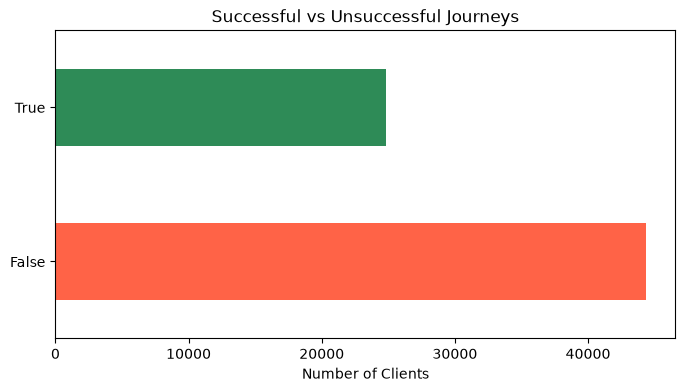

In [14]:
success_counts.plot(
    kind='barh',
    color=['tomato', 'seagreen'],
    figsize=(8,4)
)

plt.title('Successful vs Unsuccessful Journeys')
plt.xlabel('Number of Clients')
plt.ylabel('')

plt.show()

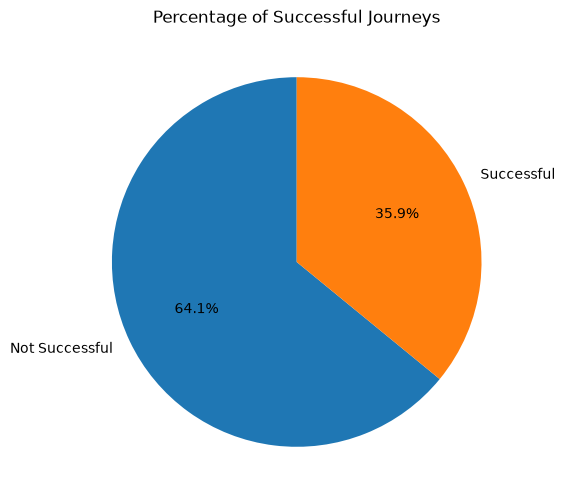

In [15]:
plt.figure(figsize=(6,6))

plt.pie(
    success_counts,
    labels=['Not Successful', 'Successful'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Percentage of Successful Journeys')
plt.show()

Compare Success Rate by Test vs Control

In [16]:
pd.crosstab(
    journeys['Variation'],
    journeys['is_successful'],
    normalize='index'
) * 100

is_successful,False,True
Variation,,
Control,64.863014,35.136986
Test,63.402993,36.597007


In [17]:
success_by_group = pd.crosstab(
    journeys['Variation'],
    journeys['is_successful'],
    normalize='index'
) * 100

A total of 24,858 clients completed the full sequence (start → step_1 → step_2 → step_3 → confirm), representing a success rate of 35.9%. Conversely, 64.1% of clients did not complete all required steps, indicating substantial drop-off throughout the journey.